# Deconvolution of Spatial Wavelet Coefficient Representation of Chromatin Images
February 15, 2024

A notebook to test the idea of whether we can deconvolve wavelet coefficients of the chromatin image data.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [14]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [34]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)

In [63]:
chrom_wavelets.create_coefficients()

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


In [68]:
recon_coefficients_mat = chrom_wavelets.convert_vectorized_coeffs_to_mat(chrom_wavelets.coeffs_vec)
recon_coefficients_mat.shape

(16, 4, 12, 29)

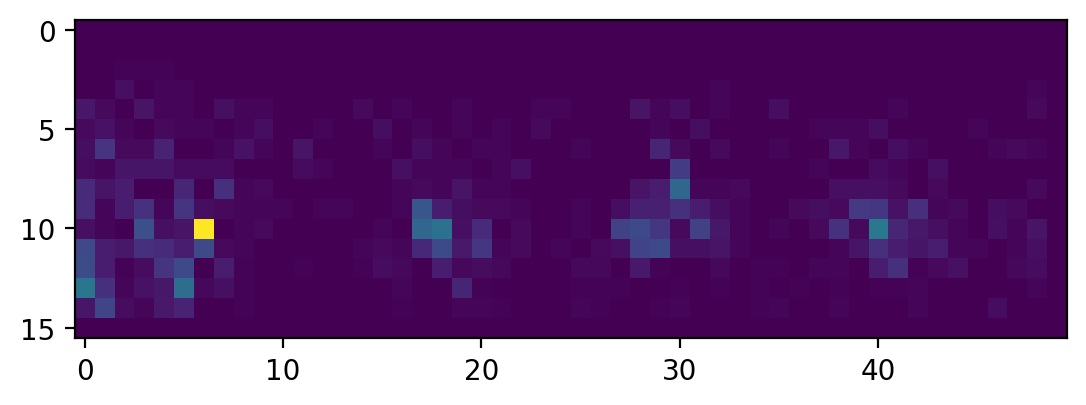

In [72]:
imgs = chrom_wavelets.reconstruct_images(recon_coefficients_mat)
plt.imshow(imgs[0])

In [73]:
# Now, can we deconvolve the coefficients vector?

In [75]:
chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

In [ ]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

G = chrom_wavelets.coeffs_vec
f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, G, verbose=True)
